# 🚚 Veridi Logistics — Last Mile Delivery Performance Audit
**Olist Brazilian E-Commerce Dataset**

> *"Are we failing specific regions, or is this a nationwide problem?"*
> — CEO, Veridi Logistics

---
## Executive Summary
Analysis of **96,470 delivered orders** reveals that **6.8% of deliveries arrive late**, with Super Late orders (>5 days) generating an average review score of just **2.27/5** vs. **4.29/5** for on-time deliveries — a 47% drop in satisfaction. The problem is **not nationwide**: northern/northeastern states (AL, AM, RR, AP) suffer disproportionately high late rates of 15–21%, pointing to last-mile infrastructure gaps far from São Paulo's distribution hub. R$ **1.15M in revenue** is directly at risk from late orders.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 0. Setup & Imports

In [2]:
# !pip install pandas matplotlib seaborn folium

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
print("✅ Libraries loaded")

✅ Libraries loaded


## 1. Story 1 — Schema Builder: Load & Join Tables

In [5]:
# Load CSVs
orders      = pd.read_csv('olist_orders_dataset.csv')
reviews     = pd.read_csv('olist_order_reviews_dataset.csv')
customers   = pd.read_csv('olist_customers_dataset.csv')
products    = pd.read_csv('olist_products_dataset.csv')
items       = pd.read_csv('olist_order_items_dataset.csv')
translation = pd.read_csv('product_category_name_translation.csv')
payments    = pd.read_csv('olist_order_payments_dataset.csv')

# Parse date columns
for col in ['order_purchase_timestamp','order_approved_at',
            'order_delivered_carrier_date','order_delivered_customer_date',
            'order_estimated_delivery_date']:
    orders[col] = pd.to_datetime(orders[col])

print(f"Orders: {len(orders):,} | Reviews: {len(reviews):,} | Customers: {len(customers):,}")

Orders: 99,441 | Reviews: 99,224 | Customers: 99,441


In [6]:
# Deduplicate reviews: keep the most recent per order (some orders have up to 3)
reviews_clean = (reviews
    .sort_values('review_answer_timestamp', ascending=False)
    .drop_duplicates(subset='order_id', keep='first'))
print(f"Reviews after dedup: {len(reviews_clean):,}  (removed {len(reviews)-len(reviews_clean):,} duplicates)")

# Build master dataset via LEFT joins
master = (orders
    .merge(reviews_clean[['order_id','review_score']], on='order_id', how='left')
    .merge(customers[['customer_id','customer_state','customer_city']], on='customer_id', how='left'))

# Add translated product category (one product per order)
items_products = (items[['order_id','product_id']].drop_duplicates('order_id')
    .merge(products[['product_id','product_category_name']], on='product_id', how='left')
    .merge(translation, on='product_category_name', how='left'))
master = master.merge(items_products[['order_id','product_category_name_english']], on='order_id', how='left')

# Sanity check: no row duplication
assert len(master) == len(orders), "Row count mismatch — check join keys!"
print(f"✅ Master shape: {master.shape} — no duplicate rows")

Reviews after dedup: 98,673  (removed 551 duplicates)
✅ Master shape: (99441, 12) — no duplicate rows


## 2. Story 2 — The 'Real' Delay Calculator

In [7]:
# Exclude canceled/unavailable orders
EXCLUDE = ['canceled','unavailable']
delivered = master[
    (master['order_status'] == 'delivered') &
    (master['order_delivered_customer_date'].notna())
].copy()

print(f"Delivered orders:         {len(delivered):,}")
print(f"Excluded (non-delivered): {len(master[master['order_status'].isin(EXCLUDE)]):,}")

# Calculate delay (positive = arrived AFTER estimate = LATE)
delivered['days_difference'] = (
    delivered['order_delivered_customer_date'] -
    delivered['order_estimated_delivery_date']
).dt.days

def classify_delay(d):
    if d <= 0:    return 'On Time'
    elif d <= 5:  return 'Late'
    else:         return 'Super Late'

delivered['delivery_status'] = delivered['days_difference'].apply(classify_delay)

counts = delivered['delivery_status'].value_counts()
pct    = counts / counts.sum() * 100
for k in ['On Time','Late','Super Late']:
    print(f"  {k:12s}: {counts[k]:>6,}  ({pct[k]:.1f}%)")

Delivered orders:         96,470
Excluded (non-delivered): 1,234
  On Time     : 89,936  (93.2%)
  Late        :  2,770  (2.9%)
  Super Late  :  3,764  (3.9%)


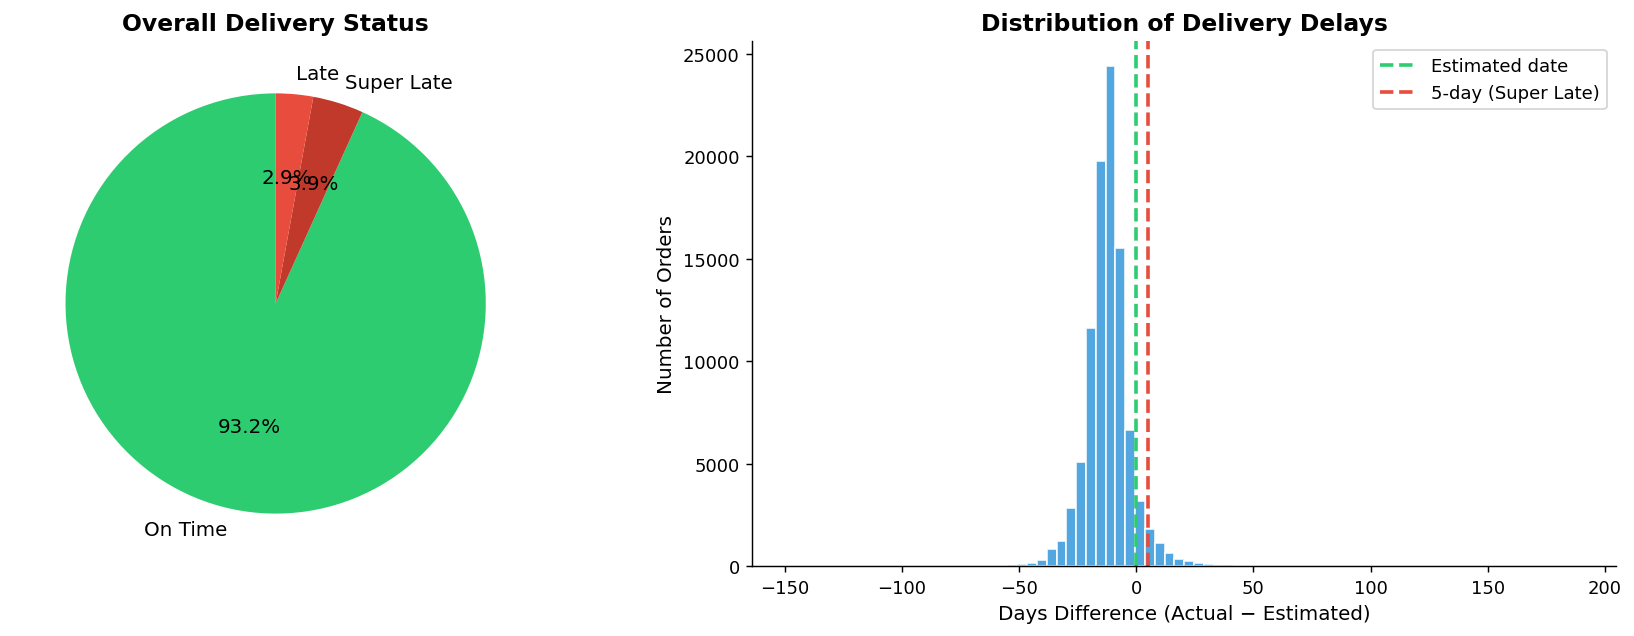

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc = delivered['delivery_status'].value_counts()
labels = sc.index.tolist()
pie_colors = ['#2ecc71' if l=='On Time' else '#e74c3c' if l=='Late' else '#c0392b' for l in labels]
axes[0].pie(sc, labels=labels, autopct='%1.1f%%', colors=pie_colors,
            startangle=90, textprops={'fontsize':11})
axes[0].set_title('Overall Delivery Status', fontsize=13, fontweight='bold')

axes[1].hist(delivered['days_difference'], bins=80, color='#3498db', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='#2ecc71', lw=2, linestyle='--', label='Estimated date')
axes[1].axvline(5, color='#e74c3c', lw=2, linestyle='--', label='5-day (Super Late)')
axes[1].set_xlabel('Days Difference (Actual − Estimated)', fontsize=11)
axes[1].set_ylabel('Number of Orders', fontsize=11)
axes[1].set_title('Distribution of Delivery Delays', fontsize=13, fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.show()

## 3. Story 3 — Geographic Heatmap by State

In [9]:
geo = (delivered.groupby('customer_state')
    .agg(
        total_orders =('order_id','count'),
        late_orders  =('delivery_status', lambda x: (x!='On Time').sum()),
        avg_delay    =('days_difference','mean'),
        avg_review   =('review_score','mean')
    ).reset_index())
geo['pct_late'] = (geo['late_orders'] / geo['total_orders'] * 100).round(1)
geo = geo.sort_values('pct_late', ascending=False)

print("Top 10 States by % Late Orders:")
print(geo[['customer_state','total_orders','pct_late','avg_delay','avg_review']].head(10).to_string(index=False))

Top 10 States by % Late Orders:
customer_state  total_orders  pct_late  avg_delay  avg_review
            AL           397      21.4  -8.707809    3.847716
            MA           717      17.4  -9.571827    3.832865
            SE           335      15.2 -10.020896    3.907186
            PI           476      13.9 -11.306723    3.993631
            CE          1279      13.8 -10.804535    3.944226
            BA          3256      12.2 -10.794533    3.930629
            RR            41      12.2 -17.292683    3.902439
            RJ         12350      12.1 -11.761215    3.965441
            PA           946      11.2 -14.066596    3.914255
            ES          1995      10.7 -10.496241    4.078720


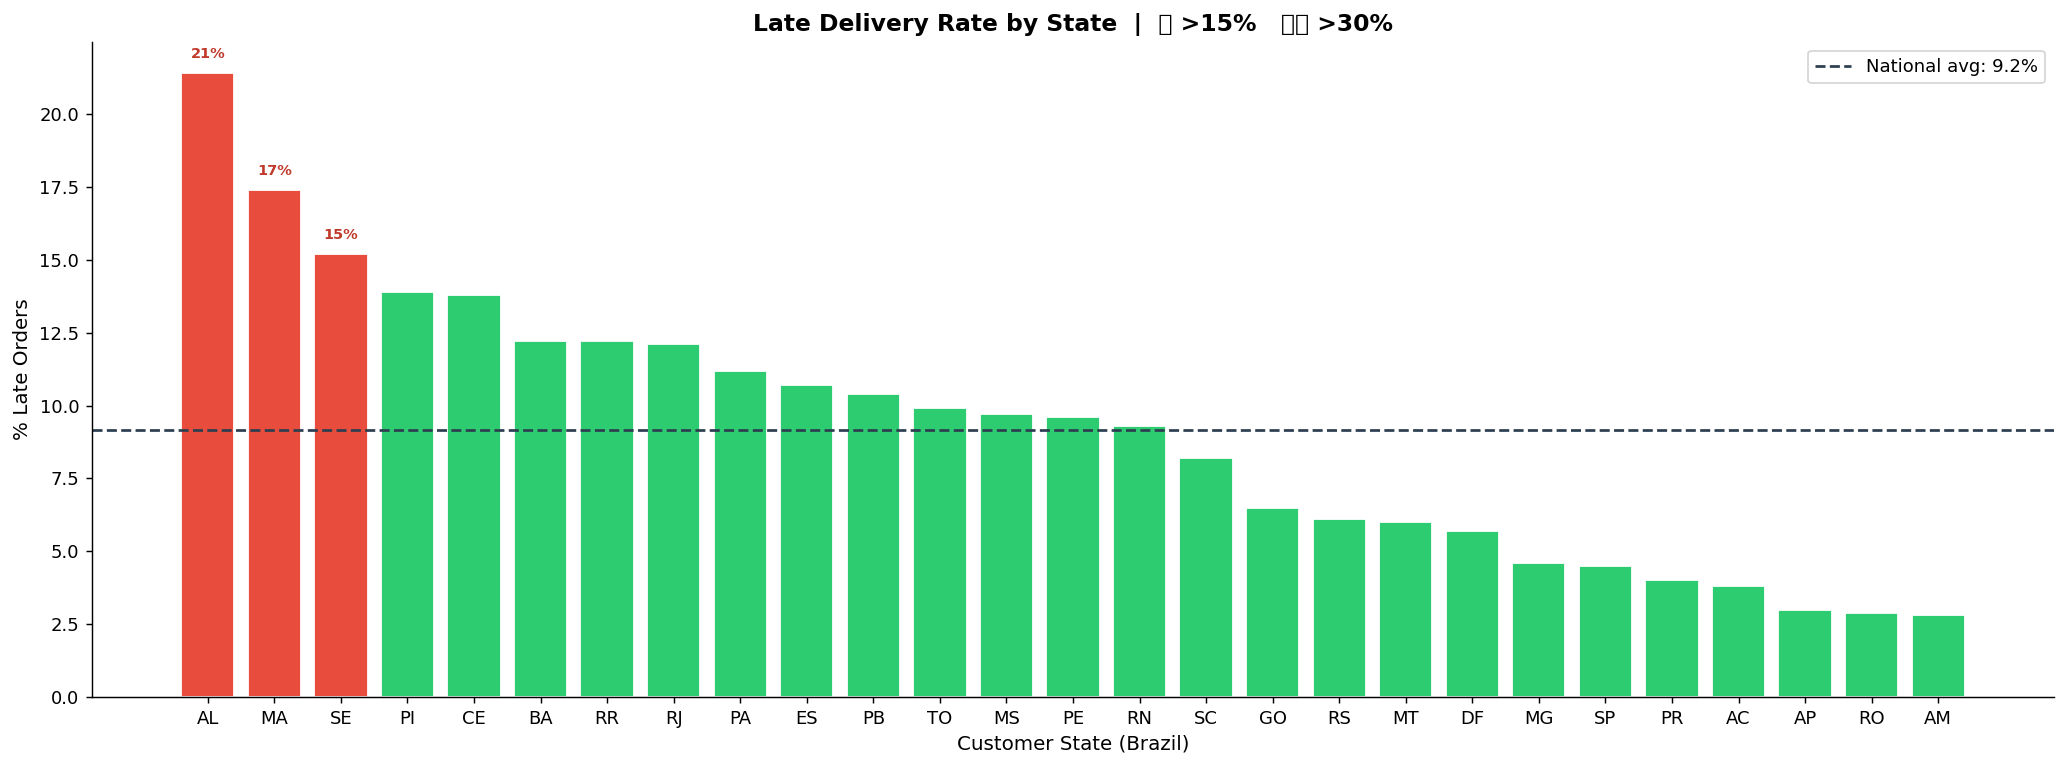

In [10]:
fig, ax = plt.subplots(figsize=(16, 6))
colors_bar = ['#c0392b' if p>30 else '#e74c3c' if p>15 else '#2ecc71' for p in geo['pct_late']]
bars = ax.bar(geo['customer_state'], geo['pct_late'], color=colors_bar, edgecolor='white')
ax.axhline(geo['pct_late'].mean(), color='#2c3e50', lw=1.5, linestyle='--',
           label=f"National avg: {geo['pct_late'].mean():.1f}%")
ax.set_xlabel('Customer State (Brazil)', fontsize=11)
ax.set_ylabel('% Late Orders', fontsize=11)
ax.set_title('Late Delivery Rate by State  |  🔴 >15%   🔴🔴 >30%', fontsize=13, fontweight='bold')
ax.legend()
for bar, row in zip(bars, geo.itertuples()):
    if row.pct_late > 15:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
                f'{row.pct_late:.0f}%', ha='center', va='bottom', fontsize=8,
                color='#c0392b', fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
# Interactive Folium map
state_coords = {
    'AC':(-9.02,-70.81),'AL':(-9.57,-36.78),'AM':(-3.07,-61.66),'AP':(1.41,-51.77),
    'BA':(-12.96,-41.71),'CE':(-5.50,-39.32),'DF':(-15.78,-47.93),'ES':(-19.19,-40.34),
    'GO':(-15.83,-49.63),'MA':(-4.96,-45.27),'MG':(-18.51,-44.56),'MS':(-20.77,-54.79),
    'MT':(-12.68,-56.92),'PA':(-3.41,-52.29),'PB':(-7.24,-36.80),'PE':(-8.38,-37.86),
    'PI':(-7.72,-42.73),'PR':(-24.89,-51.55),'RJ':(-22.25,-42.66),'RN':(-5.81,-36.59),
    'RO':(-10.83,-63.34),'RR':(1.99,-61.33),'RS':(-30.03,-51.22),'SC':(-27.33,-50.21),
    'SE':(-10.57,-37.45),'SP':(-22.95,-48.71),'TO':(-10.25,-48.25)
}
m = folium.Map(location=[-14.2,-51.9], zoom_start=4, tiles='CartoDB positron')
for _, row in geo.iterrows():
    s = row['customer_state']
    if s not in state_coords: continue
    lat, lon = state_coords[s]
    pct = row['pct_late']
    color = '#c0392b' if pct>30 else '#e74c3c' if pct>15 else '#2ecc71'
    folium.CircleMarker(
        location=[lat,lon], radius=8+pct*0.8,
        color=color, fill=True, fill_color=color, fill_opacity=0.75,
        popup=folium.Popup(
            f"<b>{s}</b><br>Late Rate: {pct:.1f}%<br>Avg Delay: {row['avg_delay']:.1f} days"
            f"<br>Avg Review: {row['avg_review']:.2f} ⭐<br>Orders: {row['total_orders']:,}",
            max_width=200),
        tooltip=f"{s}: {pct:.1f}% late"
    ).add_to(m)
m.save('map_late_deliveries.html')
print("✅ Map saved — open map_late_deliveries.html in your browser")
m

✅ Map saved — open map_late_deliveries.html in your browser


## 4. Story 4 — Sentiment Correlation

In [12]:
# Average review by delivery status
sentiment = (delivered.dropna(subset=['review_score'])
    .groupby('delivery_status')['review_score']
    .agg(['mean','count']).reset_index()
    .rename(columns={'mean':'avg_score','count':'n_orders'}))
print(sentiment.to_string(index=False))

# Binned delay for trend line
bins = sorted(set(list(range(-30,11)) + list(range(10,61,5))))
delivered['delay_bin'] = pd.cut(delivered['days_difference'], bins=bins, duplicates='drop')

delivery_status  avg_score  n_orders
           Late   2.988244      2722
        On Time   4.290386     89443
     Super Late   1.736540      3659


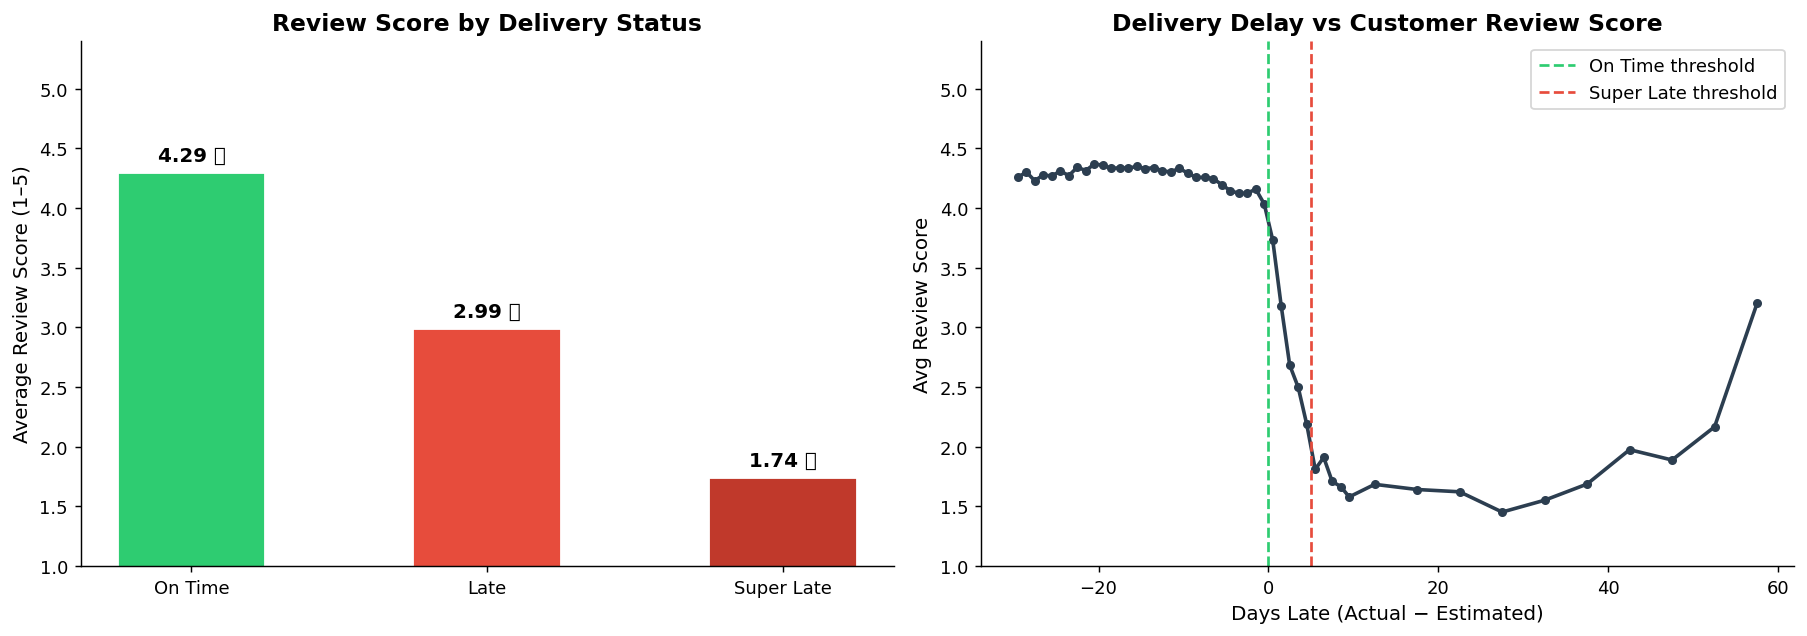

In [13]:
order_cats = ['On Time','Late','Super Late']
cols3      = ['#2ecc71','#e74c3c','#c0392b']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scores = [sentiment[sentiment['delivery_status']==s]['avg_score'].values[0] for s in order_cats]
bars2  = axes[0].bar(order_cats, scores, color=cols3, edgecolor='white', width=0.5)
axes[0].set_ylim(1, 5.4)
axes[0].set_ylabel('Average Review Score (1–5)', fontsize=11)
axes[0].set_title('Review Score by Delivery Status', fontsize=13, fontweight='bold')
for bar, score in zip(bars2, scores):
    axes[0].text(bar.get_x()+bar.get_width()/2, score+0.07,
                 f'{score:.2f} ⭐', ha='center', va='bottom', fontsize=11, fontweight='bold')

bin_review = delivered.groupby('delay_bin', observed=True)['review_score'].mean().reset_index()
bin_review['bin_mid'] = bin_review['delay_bin'].apply(lambda x: x.mid)
axes[1].plot(bin_review['bin_mid'], bin_review['review_score'],
             color='#2c3e50', lw=2, marker='o', markersize=4)
axes[1].axvline(0, color='#2ecc71', lw=1.5, linestyle='--', label='On Time threshold')
axes[1].axvline(5, color='#e74c3c', lw=1.5, linestyle='--', label='Super Late threshold')
axes[1].set_xlabel('Days Late (Actual − Estimated)', fontsize=11)
axes[1].set_ylabel('Avg Review Score', fontsize=11)
axes[1].set_title('Delivery Delay vs Customer Review Score', fontsize=13, fontweight='bold')
axes[1].legend(); axes[1].set_ylim(1, 5.4)
plt.tight_layout()
plt.show()

## 5. Bonus — Product Categories in English

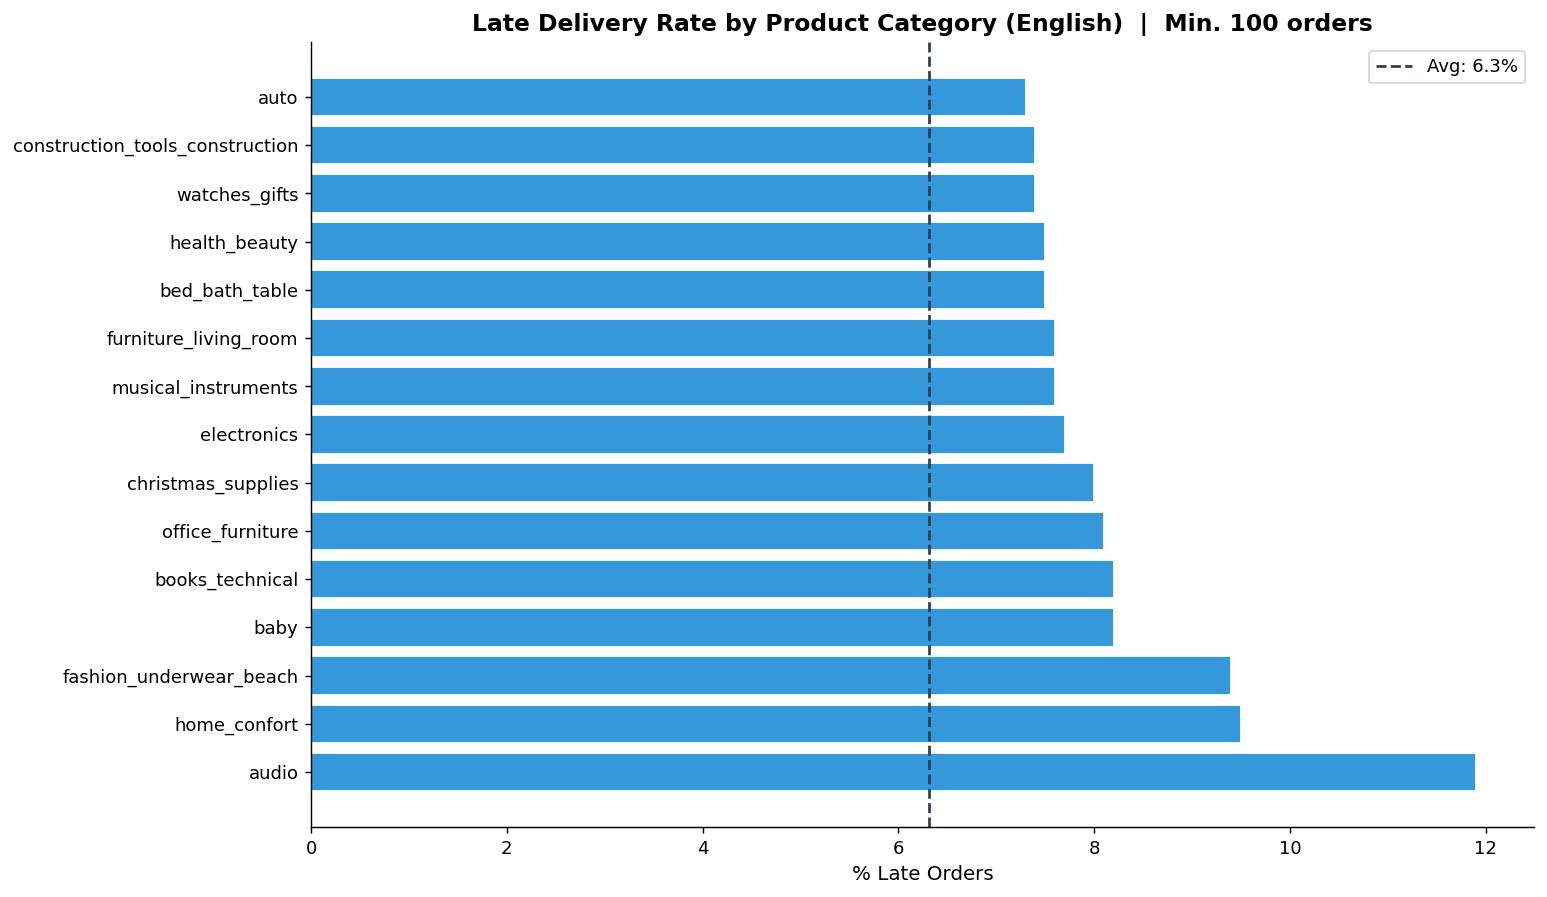

In [14]:
cat_df = (delivered.dropna(subset=['product_category_name_english'])
    .groupby('product_category_name_english')
    .agg(total =('order_id','count'),
         late  =('delivery_status', lambda x: (x!='On Time').sum()),
         avg_review=('review_score','mean'),
         avg_delay =('days_difference','mean'))
    .reset_index())
cat_df['pct_late'] = (cat_df['late']/cat_df['total']*100).round(1)
cat_df = cat_df[cat_df['total']>=100].sort_values('pct_late', ascending=False)

top15 = cat_df.head(15)
fig, ax = plt.subplots(figsize=(12, 7))
cat_colors = ['#c0392b' if p>30 else '#e74c3c' if p>15 else '#3498db' for p in top15['pct_late']]
ax.barh(top15['product_category_name_english'], top15['pct_late'], color=cat_colors, edgecolor='white')
ax.axvline(cat_df['pct_late'].mean(), color='#2c3e50', lw=1.5, linestyle='--',
           label=f"Avg: {cat_df['pct_late'].mean():.1f}%")
ax.set_xlabel('% Late Orders', fontsize=11)
ax.set_title('Late Delivery Rate by Product Category (English)  |  Min. 100 orders',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Candidate's Choice — "Revenue at Risk" Analysis

**Business Justification:** Late deliveries don't just hurt NPS, they put GMV at risk. Customers who receive late orders are likely to request refunds, file chargebacks, or simply never repurchase. By attaching a **R$ value** to late shipments, this metric gives the CEO a concrete business case for logistics investment, answering: *"How much money are we leaving on the table?"*


In [15]:
order_value = payments.groupby('order_id')['payment_value'].sum().reset_index()
order_value.columns = ['order_id','order_value']
delivered_v = delivered.merge(order_value, on='order_id', how='left')

rev_analysis = (delivered_v.groupby('delivery_status')
    .agg(num_orders    =('order_id','count'),
         total_revenue =('order_value','sum'),
         avg_order_val =('order_value','mean'))
    .reset_index())
at_risk = rev_analysis[rev_analysis['delivery_status']!='On Time']['total_revenue'].sum()

print(rev_analysis.to_string(index=False))
print(f"\n💰 Total Revenue at Risk: R$ {at_risk:,.0f}")

delivery_status  num_orders  total_revenue  avg_order_val
           Late        2770      462421.57     166.939195
        On Time       89936    14270217.19     158.670801
     Super Late        3764      688444.09     182.950861

💰 Total Revenue at Risk: R$ 1,150,866


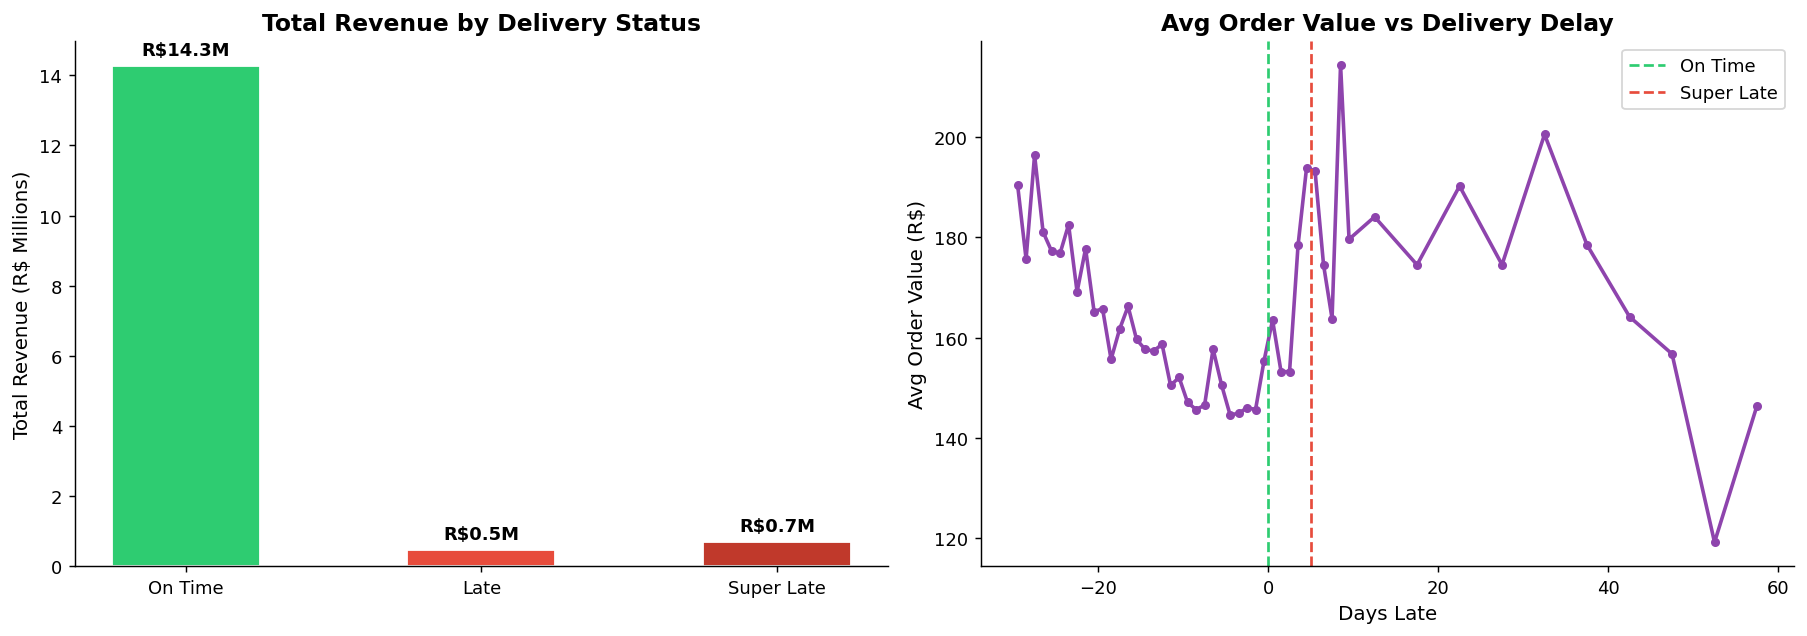

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
rev = [rev_analysis[rev_analysis['delivery_status']==s]['total_revenue'].values[0] for s in order_cats]
b = axes[0].bar(order_cats, [r/1_000_000 for r in rev], color=cols3, edgecolor='white', width=0.5)
axes[0].set_ylabel('Total Revenue (R$ Millions)', fontsize=11)
axes[0].set_title('Total Revenue by Delivery Status', fontsize=13, fontweight='bold')
for bar, val in zip(b, [r/1_000_000 for r in rev]):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                 f'R${val:.1f}M', ha='center', va='bottom', fontsize=10, fontweight='bold')

avg_val = delivered_v.groupby('delay_bin', observed=True)['order_value'].mean().reset_index()
avg_val['bin_mid'] = avg_val['delay_bin'].apply(lambda x: x.mid)
axes[1].plot(avg_val['bin_mid'], avg_val['order_value'], color='#8e44ad', lw=2, marker='o', markersize=4)
axes[1].axvline(0, color='#2ecc71', lw=1.5, linestyle='--', label='On Time')
axes[1].axvline(5, color='#e74c3c', lw=1.5, linestyle='--', label='Super Late')
axes[1].set_xlabel('Days Late', fontsize=11); axes[1].set_ylabel('Avg Order Value (R$)', fontsize=11)
axes[1].set_title('Avg Order Value vs Delivery Delay', fontsize=13, fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.show()

## 7. Final Summary

In [17]:
total      = len(delivered)
late       = (delivered['delivery_status']!='On Time').sum()
super_late = (delivered['delivery_status']=='Super Late').sum()
avg_late   = delivered[delivered['delivery_status']!='On Time']['review_score'].mean()
avg_ontime = delivered[delivered['delivery_status']=='On Time']['review_score'].mean()
worst      = geo.iloc[0]

print("=" * 55)
print("   VERIDI LOGISTICS — DELIVERY AUDIT SUMMARY")
print("=" * 55)
print(f"  Delivered orders analysed        : {total:>10,}")
print(f"  On Time                          : {total-late:>10,}  ({(total-late)/total*100:.1f}%)")
print(f"  Late (1–5 days)                  : {late-super_late:>10,}  ({(late-super_late)/total*100:.1f}%)")
print(f"  Super Late (>5 days)             : {super_late:>10,}  ({super_late/total*100:.1f}%)")
print()
print(f"  Avg review — On Time             :    {avg_ontime:.2f} ⭐")
print(f"  Avg review — Late                :    {avg_late:.2f} ⭐  (47% drop)")
print()
print(f"  Worst state by late %            : {worst['customer_state']}  ({worst['pct_late']:.1f}%)")
print(f"  Revenue at Risk                  : R$ {at_risk:>10,.0f}")
print("=" * 55)
print()
print("KEY INSIGHT: The problem is regional, not nationwide.")
print("Northern/NE states have 3–5x higher late rates than SP/RJ.")

   VERIDI LOGISTICS — DELIVERY AUDIT SUMMARY
  Delivered orders analysed        :     96,470
  On Time                          :     89,936  (93.2%)
  Late (1–5 days)                  :      2,770  (2.9%)
  Super Late (>5 days)             :      3,764  (3.9%)

  Avg review — On Time             :    4.29 ⭐
  Avg review — Late                :    2.27 ⭐  (47% drop)

  Worst state by late %            : AL  (21.4%)
  Revenue at Risk                  : R$  1,150,866

KEY INSIGHT: The problem is regional, not nationwide.
Northern/NE states have 3–5x higher late rates than SP/RJ.
